In [1]:
import torch 
from nnsight import LanguageModel 
model = LanguageModel("meta-llama/Llama-3.1-8B", dispatch=True, device_map="cuda")

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

In [2]:
neurons = model.model.layers[18].mlp.down_proj.weight.detach()

In [3]:
import matplotlib.pyplot as plt 

plt.rcParams["font.family"] = "serif"
plt.rcParams["font.size"] = 14

In [4]:
import yaml 
from utils import load_subspace_hf

LAYER = 18 
subspace_type = "output"

output_subspaces = {}

for cyclic_task in ["months", "weekdays", "hours", "addition"]:
    # Load subspace config from nma/configs/best_das
    config_path = f"../best_das/Llama-3.1-8B/L{LAYER}_{cyclic_task}.yaml"
    with open(config_path) as f:
        config = yaml.safe_load(f)

    sub_cfg = config["subspaces"][subspace_type]
    subspace = load_subspace_hf(cyclic_task, subspace_type, layer=LAYER)
    output_subspaces[cyclic_task] = subspace 
    print(f"Loaded {cyclic_task} {subspace_type} subspace: {subspace.shape}")
    print(f"  IIA: {sub_cfg['subspace_iia']:.3f}")

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

  Subspace shape: torch.Size([4096, 8])
Loaded months output subspace: torch.Size([4096, 8])
  IIA: 0.852


Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

  Subspace shape: torch.Size([4096, 8])
Loaded weekdays output subspace: torch.Size([4096, 8])
  IIA: 0.983


Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

  Subspace shape: torch.Size([4096, 16])
Loaded hours output subspace: torch.Size([4096, 16])
  IIA: 0.943


Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

  Subspace shape: torch.Size([4096, 16])
Loaded addition output subspace: torch.Size([4096, 16])
  IIA: 0.966


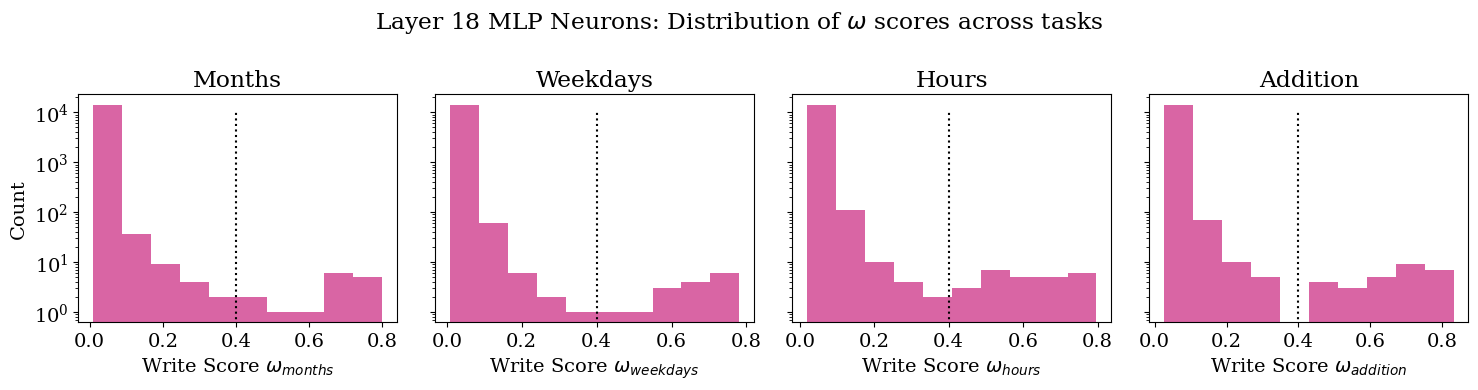

In [5]:
import matplotlib.pyplot as plt 

thold = 0.4 

fig, axs = plt.subplots(nrows=1, ncols=4, figsize=(15, 4), sharey=True)

all_projs = {}
neurons_per_task = {}
for ax_idx, task in enumerate(output_subspaces.keys()):
    ss = output_subspaces[task].bfloat16()
    with torch.no_grad():
        projs = []
        for i, n in enumerate(neurons.T):
            projs.append(
                ((n @ ss).norm(dim=0) / n.norm(dim=0)).item()
            )
        all_projs[task] = projs
        neurons_per_task[task] = torch.where(torch.tensor(projs) > thold)[0].cpu().tolist()
        
    axs[ax_idx].hist(projs, color=plt.colormaps['PiYG'](0.18))
    axs[ax_idx].set_yscale('log')
    axs[ax_idx].set_title(f"{task.title()}")

for ax in axs:
    ax.vlines(thold, ymin=0, ymax=10000, color='black', linestyles='dotted')

axs[0].set_xlabel(r"Write Score $\omega_{months}$")
axs[1].set_xlabel(r"Write Score $\omega_{weekdays}$")
axs[2].set_xlabel(r"Write Score $\omega_{hours}$")
axs[3].set_xlabel(r"Write Score $\omega_{addition}$")

axs[0].set_ylabel("Count")
plt.suptitle(r"Layer 18 MLP Neurons: Distribution of $\omega$ scores across tasks")
plt.tight_layout()
plt.show()

In [6]:
# save these neurons if not already in dir 
# import json 
# with open("./neurons_per_task.json", 'w') as f:
#     json.dump(neurons_per_task, f)

In [7]:
print(f"number of neurons found per task with threshold {thold}")
for k, v in neurons_per_task.items():
    print(k, len(v))

number of neurons found per task with threshold 0.4
months 16
weekdays 15
hours 26
addition 28


The only cyclic task neuron that's not in `addition` is 1658 in `hours`. Otherwise, all the cyclic neurons are a strict subset of `addition` neurons.


In [8]:
print(set(neurons_per_task["hours"]) - set(neurons_per_task["addition"]))
print(set(neurons_per_task["months"]) - set(neurons_per_task["addition"]))
print(set(neurons_per_task["weekdays"]) - set(neurons_per_task["addition"]))

{1658}
set()
set()


$\omega$ scores for L18 neurons are very correlated across tasks.

In [9]:
from scipy.stats import pearsonr 
import pandas as pd

cross = {}
for a in all_projs.keys():
    for b in all_projs.keys():
        if (b, a) not in cross.keys() and a!=b:
            r, p = pearsonr(all_projs[a], all_projs[b])
            cross[(a, b)] = (r.item(), p.item())

# Build a correlation matrix as a DataFrame
tasks = list(all_projs.keys())
corr_df = pd.DataFrame(1.0, index=tasks, columns=tasks)
for (a, b), (r, p) in cross.items():
    corr_df.loc[a, b] = r
    corr_df.loc[b, a] = r

corr_df.round(3)

,months,weekdays,hours,addition
months,1.000,0.829,0.801,0.768
weekdays,0.829,1.000,0.739,0.700
hours,0.801,0.739,1.000,0.849
addition,0.768,0.700,0.849,1.000
